# Module 3.1 — Turbulence Basics

**Why turbulence is called the last unsolved problem in classical physics:**
Nearly every engineering flow is turbulent — yet there is no general analytical solution to the turbulent Navier-Stokes equations. The $1,000,000 Clay Millennium Prize for solving N-S has been unclaimed since 2000. You have been solving laminar flows in Module 2. This module explains why that approach breaks down at high Reynolds numbers and what to do about it.

**What makes turbulence hard — three properties that interact:**
- **Multi-scale:** eddies exist from metres down to sub-millimetre sizes, all simultaneously
- **Nonlinear:** eddies interact with each other through the convective term $(\mathbf{u}\cdot\nabla)\mathbf{u}$
- **Chaotic:** two flows with microscopically similar initial conditions diverge completely after a short time

**Roadmap:**
1. The energy cascade — what turbulence actually looks like across scales
2. Kolmogorov microscales — the smallest eddies and why DNS is infeasible
3. Reynolds decomposition — the mathematical split between mean and fluctuation
4. The RANS equations — derived step by step from first principles
5. The closure problem — why there are always more unknowns than equations
6. Boussinesq hypothesis — eddy viscosity as the simplest closure
7. Prandtl mixing-length — deriving the law of the wall from physics
8. Overview of turbulence model hierarchy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Energy Cascade

### What turbulence looks like

At low Reynolds number (Re = 100, your cavity flow), the flow has one smooth vortex. As Re increases, that vortex becomes unstable and breaks into smaller vortices. Those break into smaller ones — until the eddies are small enough for viscosity to convert their kinetic energy to heat.

This is the **energy cascade** (Richardson, 1922):

```
Large eddies (size L)    ← Energy injected by mean shear (stirring the flow)
       ↓ break up            Inertia >> viscosity at this scale
Medium eddies (ℓ)         Energy transferred — no net production or loss
       ↓ break up            This range: E(k) ∝ k^(-5/3)  ← Kolmogorov's prediction
Small eddies (η)          ← Viscosity converts kinetic energy to heat
```

### Why eddies break up

A large eddy has Re = $u_\ell \ell / \nu \gg 1$ — inertia dominates. It is **unstable** (Kelvin-Helmholtz instability) and breaks apart. The child eddies also have Re >> 1 and also break up. This continues until the eddies are small enough that Re $\approx$ 1 — viscosity can now act.

### Kolmogorov microscales (1941)

At what size does Re = 1? Using only $\nu$ [m²/s] and $\varepsilon$ [m²/s³] (the energy dissipation rate per unit mass — the only relevant quantities at small scales):

$$\boxed{\eta = \left(\frac{\nu^3}{\varepsilon}\right)^{1/4}} \quad \text{(Kolmogorov length scale)}$$

$$u_\eta = (\nu\varepsilon)^{1/4}, \qquad \tau_\eta = \left(\frac{\nu}{\varepsilon}\right)^{1/2}$$

**Verify Re = 1 at the Kolmogorov scale:**
$Re_\eta = u_\eta \eta / \nu = (\nu\varepsilon)^{1/4} (\nu^3/\varepsilon)^{1/4} / \nu = \nu^{1/2}\nu^{3/4}/\nu = 1$ ✓

### How small are the Kolmogorov scales?

Assuming $\varepsilon \sim U^3/L$ (energy injected at the large scale must equal dissipation at the small scale in equilibrium):

$$\frac{\eta}{L} \sim Re_L^{-3/4}$$

For Re = $10^6$ (aircraft wing): $\eta/L \sim 10^{-4.5} \approx 3\times10^{-5}$

If $L = 1$ m, then $\eta \approx 30\,\mu$m — a grain of fine sand.

### Why DNS is infeasible at engineering Reynolds numbers

**DNS (Direct Numerical Simulation)** resolves every eddy down to $\eta$, requiring $\Delta x \approx \eta$:

$$\text{Grid points in 3D} \sim \left(\frac{L}{\eta}\right)^3 \sim Re_L^{9/4}$$

| Re | 3D grid points | Feasible? |
|----|---------------|----------|
| 100 (your cavity) | ~1,500 | ✅ Trivial |
| 10,000 (turbulent pipe) | ~$10^9$ | ⚠️ Supercomputer |
| $10^6$ (aircraft wing) | ~$10^{13}$ | ❌ Impossible |
| $10^8$ (ocean current) | ~$10^{18}$ | ❌ Atoms in a grain of sand |

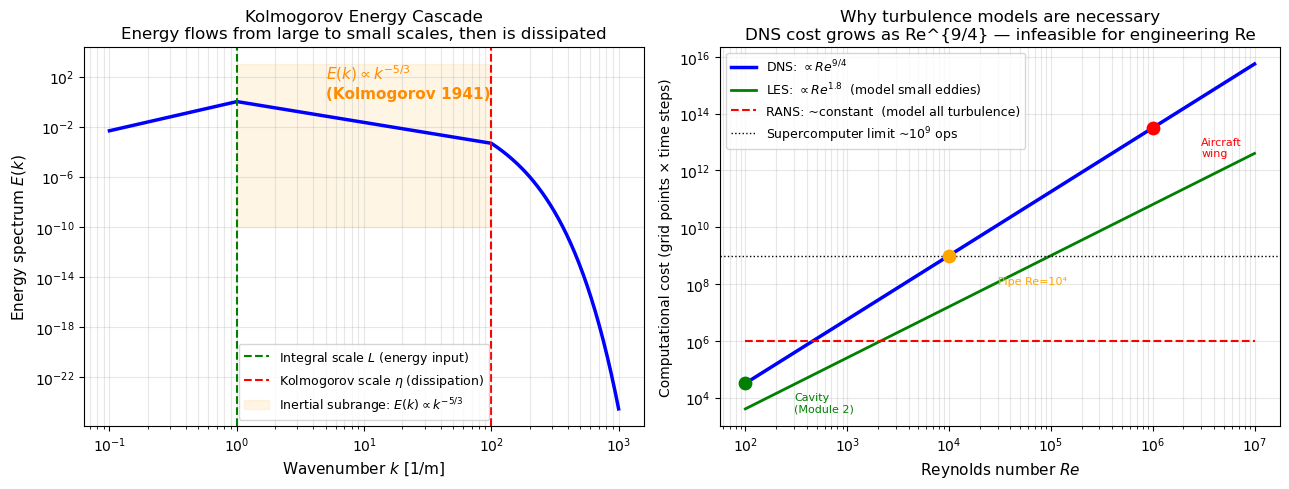

Kolmogorov scale at different Re (L=1m, ε ~ U³/L):
  Re=1e+04: η = 1000.0 μm,  DNS needs ~1.0e+09 cells in 3D
  Re=1e+06: η = 31.6 μm,  DNS needs ~3.2e+13 cells in 3D
  Re=1e+08: η = 1.0 μm,  DNS needs ~1.0e+18 cells in 3D


In [2]:
# ── Energy cascade visualisation ─────────────────────────────────────────────
# Left: E(k) ~ k^(-5/3) in the inertial subrange
# Right: DNS cost scaling — shows why turbulence models are necessary

# ── Energy spectrum ───────────────────────────────────────────────────────────
k    = np.logspace(-1, 3, 500)
# Synthesise a realistic energy spectrum
E    = k**(-5/3)
E[k > 100] *= np.exp(-(k[k > 100] - 100) / 20)   # dissipation roll-off
E[k < 1]   *= (k[k < 1])**4                        # energy-containing range build-up

# ── DNS cost ─────────────────────────────────────────────────────────────────
Re_arr = np.logspace(2, 7, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Energy spectrum
ax1.loglog(k, E, 'b-', lw=2.5)
ax1.axvline(1,   color='green', ls='--', lw=1.5, label='Integral scale $L$ (energy input)')
ax1.axvline(100, color='red',   ls='--', lw=1.5, label='Kolmogorov scale $\\eta$ (dissipation)')
ax1.fill_betweenx([1e-10, 1e3], 1, 100, alpha=0.1, color='orange',
                   label='Inertial subrange: $E(k) \\propto k^{-5/3}$')
ax1.text(5, 2e0, '$E(k) \\propto k^{-5/3}$\n(Kolmogorov 1941)', fontsize=11,
         color='darkorange', fontweight='bold')
ax1.set_xlabel('Wavenumber $k$ [1/m]', fontsize=11)
ax1.set_ylabel('Energy spectrum $E(k)$', fontsize=11)
ax1.set_title('Kolmogorov Energy Cascade\n'
              'Energy flows from large to small scales, then is dissipated')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)

# DNS cost
ax2.loglog(Re_arr, Re_arr**(9/4),  'b-', lw=2.5, label='DNS: $\\propto Re^{9/4}$')
ax2.loglog(Re_arr, Re_arr**(1.8),  'g-', lw=2,   label='LES: $\\propto Re^{1.8}$  (model small eddies)')
ax2.loglog(Re_arr, np.full_like(Re_arr, 1e6), 'r--', lw=1.5, label='RANS: ~constant  (model all turbulence)')
ax2.axhline(1e9, color='k', ls=':', lw=1, label='Supercomputer limit ~$10^9$ ops')

# Mark specific Re values
re_marks = [(100, 'Cavity\n(Module 2)'), (1e4, 'Pipe Re=10⁴'), (1e6, 'Aircraft\nwing')]
colors_m  = ['green', 'orange', 'red']
for (Re_m, lbl), col in zip(re_marks, colors_m):
    cost = Re_m**(9/4)
    ax2.scatter([Re_m], [cost], c=col, s=80, zorder=5)
    ax2.annotate(lbl, xy=(Re_m, cost), xytext=(Re_m*3, cost*0.1),
                 fontsize=8, color=col)

ax2.set_xlabel('Reynolds number $Re$', fontsize=11)
ax2.set_ylabel('Computational cost (grid points × time steps)', fontsize=10)
ax2.set_title('Why turbulence models are necessary\n'
              'DNS cost grows as Re^{9/4} — infeasible for engineering Re')
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print('Kolmogorov scale at different Re (L=1m, ε ~ U³/L):')
for Re_v, U_v in [(1e4, 1.0), (1e6, 10.0), (1e8, 100.0)]:
    nu_v = U_v * 1.0 / Re_v
    eps  = U_v**3 / 1.0
    eta  = (nu_v**3 / eps)**0.25
    print(f'  Re={Re_v:.0e}: η = {eta*1e6:.1f} μm,  DNS needs ~{(1.0/eta)**3:.1e} cells in 3D')

## 2. Reynolds Decomposition

### The problem with turbulent signals

At a point in a turbulent flow, the velocity $u(t)$ oscillates randomly around a mean. You cannot solve N-S for every fluctuation — that is DNS. Instead, **separate** the signal:

$$u = \underbrace{\bar{u}}_{\text{time mean}} + \underbrace{u'}_{\text{fluctuation}}$$

$$\bar{u} = \lim_{T\to\infty}\frac{1}{T}\int_0^T u\,dt, \qquad \overline{u'} = 0 \text{ by definition}$$

### The four averaging rules — critical for deriving RANS

| Rule | Expression | Physical meaning |
|------|-----------|------------------|
| Mean of fluctuation | $\overline{u'} = 0$ | Definition of mean |
| Mean of mean | $\bar{\bar{u}} = \bar{u}$ | Mean is already steady |
| Linearity | $\overline{u+v} = \bar{u}+\bar{v}$ | Integral is linear |
| **Products** | $\overline{uv} = \bar{u}\bar{v} + \overline{u'v'}$ | **Non-trivial — this is the key** |

The last rule is what makes turbulence hard. Even though $\overline{u'} = 0$ and $\overline{v'} = 0$ individually, their **correlation** $\overline{u'v'} \neq 0$ in general. This correlation is turbulent momentum transport.

### Why $\overline{u'v'} \neq 0$ — physical picture near a wall

Near a wall, two events dominate:

**Sweep**: fast-moving fluid from the core is thrown toward the wall: $u' > 0$ (faster than mean), $v' < 0$ (moving wall-ward). Product: $u'v' < 0$.

**Ejection**: slow-moving fluid near the wall is lifted away: $u' < 0$ (slower than mean), $v' > 0$ (moving away from wall). Product: $u'v' < 0$ again.

Both events give $u'v' < 0$ → $\overline{u'v'} < 0$ near a wall. This is **turbulent momentum transport** — the flow actively mixes high and low momentum fluid, acting as an extra viscosity.

## 3. Deriving the RANS Equations

### Step-by-step derivation

**Start** with incompressible N-S: $\partial_t u_i + u_j \partial_j u_i = -\partial_i p/\rho + \nu \partial_{jj} u_i$

**Substitute** $u_i = \bar{u}_i + u'_i$. The nonlinear term expands:

$$u_j \partial_j u_i = (\bar{u}_j + u'_j)\partial_j(\bar{u}_i + u'_i) = \bar{u}_j\partial_j\bar{u}_i + \bar{u}_j\partial_j u'_i + u'_j\partial_j\bar{u}_i + u'_j\partial_j u'_i$$

**Time-average** the whole equation. Terms with a single $u'$ vanish ($\bar{u'} = 0$). The product rule gives:

$$\overline{u'_j\partial_j u'_i} = \partial_j\overline{u'_j u'_i} \quad \text{(using continuity)}$$

**Result — the RANS momentum equation:**

$$\boxed{\frac{\partial\bar{u}_i}{\partial t} + \bar{u}_j\frac{\partial\bar{u}_i}{\partial x_j} = -\frac{1}{\rho}\frac{\partial\bar{p}}{\partial x_i} + \frac{\partial}{\partial x_j}\left[\nu\frac{\partial\bar{u}_i}{\partial x_j} - \overline{u'_i u'_j}\right]}$$

**The only difference from laminar N-S:** the Reynolds stress tensor $-\overline{u'_i u'_j}$ appears. Every turbulence model is an attempt to express this tensor in terms of mean-flow quantities.

## 4. The Closure Problem

Count unknowns vs equations:

| | Laminar N-S | RANS |
|--|------------|------|
| Mean velocities | — | $\bar{u}, \bar{v}, \bar{w}$ = 3 |
| Mean pressure | — | $\bar{p}$ = 1 |
| Reynolds stresses | — | $\overline{u'_i u'_j}$ = 6 independent |
| **Total unknowns** | 4 | **10** |
| **Equations (continuity + 3 momentum)** | 4 | **4** |

RANS has **6 more unknowns than equations**. The system is not closed.

You can derive transport equations for $\overline{u'_i u'_j}$ — but those introduce triple correlations $\overline{u'_i u'_j u'_k}$. The hierarchy never closes. **This is the closure problem.** Every turbulence model is an approximation.

### Measuring turbulence intensity

Since $\overline{u'} = 0$ always, we use the **RMS** (root-mean-square) to measure fluctuation strength:

$$u'_{\text{rms}} = \sqrt{\overline{u'^2}}$$

$$\text{Turbulence intensity} = \frac{u'_{\text{rms}}}{\bar{U}} \times 100\%$$

Typical values: pipe flow core ~3%, jet engine inlet ~5–10%, combustion chamber ~20–30%.

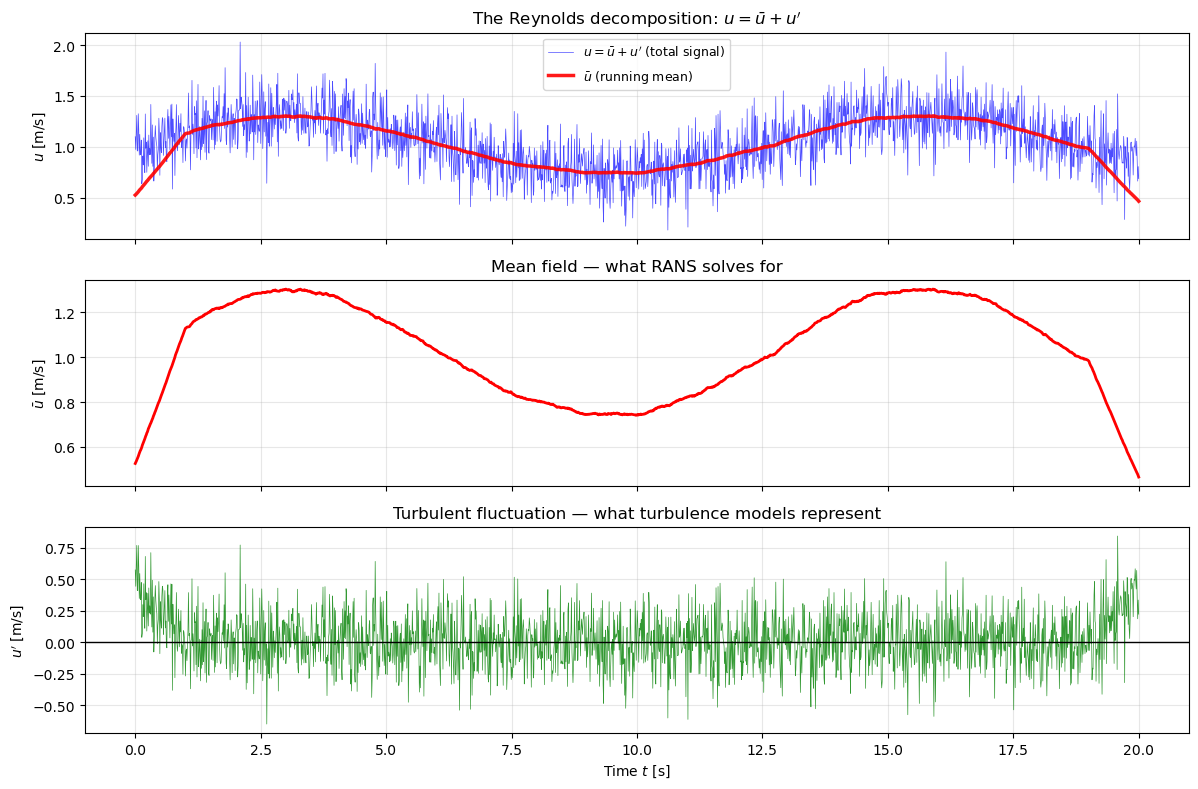

mean of u'  = 0.024117  ← should be ~0 (definition of mean)
RMS  of u'  = 0.2114   ← non-zero: real fluctuation energy
Turbulence intensity = 20.3%

Note: mean(u') = 0 always — useless as a measure of turbulence strength
      RMS(u')  > 0 always — measures the actual energy in fluctuations


In [3]:
# ── Reynolds decomposition on a synthetic turbulent signal ───────────────────

np.random.seed(42)
t = np.linspace(0, 20, 2000)

# Synthetic signal: slow mean variation + turbulent fluctuations
u_mean  = 1.0 + 0.3*np.sin(0.5*t)              # slow mean drift
u_prime = 0.2*np.random.randn(len(t))            # turbulent fluctuation
u_total = u_mean + u_prime

# Running time average (window = 200 samples)
window = 200
u_bar  = np.convolve(u_total, np.ones(window)/window, mode='same')
u_fluc = u_total - u_bar

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, u_total, 'b-', lw=0.5, alpha=0.7, label='$u = \\bar{u} + u\'$ (total signal)')
axes[0].plot(t, u_bar,   'r-', lw=2.5, alpha=0.9, label='$\\bar{u}$ (running mean)')
axes[0].set_ylabel('$u$ [m/s]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('The Reynolds decomposition: $u = \\bar{u} + u\'$')

axes[1].plot(t, u_bar, 'r-', lw=2)
axes[1].set_ylabel('$\\bar{u}$ [m/s]')
axes[1].set_title('Mean field — what RANS solves for')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, u_fluc, 'g-', lw=0.5, alpha=0.8)
axes[2].axhline(0, color='k', lw=1)
axes[2].set_ylabel("$u'$ [m/s]")
axes[2].set_xlabel('Time $t$ [s]')
axes[2].set_title("Turbulent fluctuation — what turbulence models represent")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TI = np.std(u_fluc) / np.mean(u_bar) * 100
print(f"mean of u'  = {np.mean(u_fluc):.6f}  ← should be ~0 (definition of mean)")
print(f"RMS  of u'  = {np.std(u_fluc):.4f}   ← non-zero: real fluctuation energy")
print(f"Turbulence intensity = {TI:.1f}%")
print()
print("Note: mean(u') = 0 always — useless as a measure of turbulence strength")
print("      RMS(u')  > 0 always — measures the actual energy in fluctuations")

## 5. Boussinesq Hypothesis — Eddy Viscosity

### The analogy with molecular viscosity

In laminar flow, molecular collisions transport momentum between layers, giving a viscous stress:
$$\tau_{\text{lam}} = \rho\nu\frac{d\bar{u}}{dy}$$

In turbulent flow, fluid parcels from fast-moving regions are flung into slow regions by turbulent eddies — a much more effective momentum exchange:
$$\tau_{\text{turb}} = \rho\nu_t\frac{d\bar{u}}{dy}$$

Boussinesq (1877): turbulence acts like viscosity $\nu_t$ but **much larger**.

| Property | Molecular $\nu$ | Eddy $\nu_t$ |
|----------|----------------|---------------|
| Property of | The **fluid** | The **flow state** |
| Typical value | $10^{-6}$ m²/s (water) | $10^{-2}$ m²/s (turbulent pipe) |
| Varies in space? | No (only with temperature) | Yes — 100–10,000× across the domain |
| Known before solving? | ✅ Yes — fluid property | ❌ No — must be computed by a model |

$$-\rho\overline{u'_i u'_j} = \rho\nu_t\left(\frac{\partial\bar{u}_i}{\partial x_j} + \frac{\partial\bar{u}_j}{\partial x_i}\right) - \frac{2}{3}\rho k\,\delta_{ij}$$

With this, the 6 unknown Reynolds stress components collapse to **one unknown: $\nu_t$**. Every turbulence model provides an equation or formula for $\nu_t$.

## 6. Prandtl Mixing-Length — Deriving the Law of the Wall

### Physical derivation

A fluid parcel at height $y$ above a wall is displaced by distance $\ell_m$ before mixing. It carries its original momentum to its new location. The velocity difference over that travel:

$$u' \approx \ell_m \left|\frac{d\bar{u}}{dy}\right|$$

By continuity, $v' \sim u'$. So the Reynolds shear stress:

$$|{-\overline{u'v'}}| \sim \ell_m^2\left(\frac{d\bar{u}}{dy}\right)^2$$

Comparing with Boussinesq: $\boxed{\nu_t = \ell_m^2\left|\frac{d\bar{u}}{dy}\right|}$

Near the wall: $\ell_m = \kappa y$ (parcel can't travel more than $y$ without hitting the wall). With $\kappa = 0.41$ (von Kármán constant, measured in pipe and channel flows worldwide).

### The log-law as a consequence

In a turbulent channel, total shear stress is constant: $\nu_t d\bar{u}/dy = u_\tau^2$.

Substituting $\nu_t = (\kappa y)^2 |d\bar{u}/dy|$:

$$(\kappa y)^2\left(\frac{d\bar{u}}{dy}\right)^2 = u_\tau^2 \implies \frac{d\bar{u}}{dy} = \frac{u_\tau}{\kappa y}$$

Integrating: $\bar{u} = \frac{u_\tau}{\kappa}\ln y + C$, or in wall units $u^+ = u/u_\tau$, $y^+ = yu_\tau/\nu$:

$$\boxed{u^+ = \frac{1}{\kappa}\ln(y^+) + B} \qquad \kappa = 0.41, \quad B = 5.2$$

This is the **law of the wall** — the most validated result in all of turbulence research. It has been confirmed in pipe flows, channel flows, boundary layers, and atmospheric flows worldwide.

**Why it matters for CFD:** the law of the wall determines:
- How fine your near-wall mesh must be ($y^+ \leq 1$ for resolved BL, $y^+ \approx 30$–100 for wall functions)
- The boundary conditions for turbulence quantities at the wall
- Whether your turbulence model will give correct drag predictions

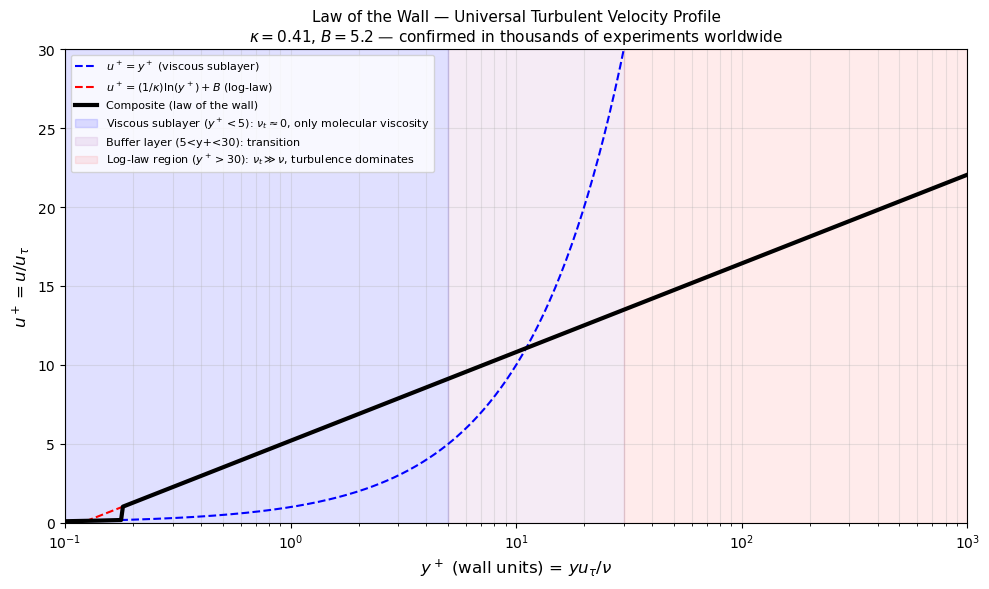

y+    | u+    | Region
-----------------------------------
  1.0 |  5.20 | Viscous sublayer
  5.0 |  9.13 | Buffer layer
 11.6 | 11.18 | Buffer layer
 30.0 | 13.50 | Log-law region
100.0 | 16.43 | Log-law region
300.0 | 19.11 | Log-law region


In [4]:
# ── Law of the Wall — three regions visualised ───────────────────────────────

kappa  = 0.41
B      = 5.2
y_plus = np.logspace(-1, 3, 500)

u_visc  = y_plus                                        # viscous sublayer: u+ = y+
u_log   = (1/kappa) * np.log(y_plus) + B               # log-law
# Composite (switch at y+ = 11.6 where the two lines cross)
y_cross = np.exp(kappa*(1.0 - B))   # solve y+ = (1/k)*ln(y+)+B
u_comp  = np.where(y_plus < y_cross, u_visc, u_log)

plt.figure(figsize=(10, 6))
plt.semilogx(y_plus, u_visc,  'b--', lw=1.5, label='$u^+ = y^+$ (viscous sublayer)')
plt.semilogx(y_plus, u_log,   'r--', lw=1.5, label=f'$u^+ = (1/\\kappa)\\ln(y^+)+B$ (log-law)')
plt.semilogx(y_plus, u_comp,  'k-',  lw=3,   label='Composite (law of the wall)')

# Shade regions
plt.axvspan(0.1,  5,   alpha=0.12, color='blue',
            label='Viscous sublayer ($y^+<5$): $\\nu_t \\approx 0$, only molecular viscosity')
plt.axvspan(5,    30,  alpha=0.08, color='purple',
            label='Buffer layer (5<y+<30): transition')
plt.axvspan(30,  1000, alpha=0.08, color='red',
            label='Log-law region ($y^+>30$): $\\nu_t \\gg \\nu$, turbulence dominates')

plt.xlabel('$y^+$ (wall units) = $y u_\\tau/\\nu$', fontsize=12)
plt.ylabel('$u^+ = u/u_\\tau$', fontsize=12)
plt.title('Law of the Wall — Universal Turbulent Velocity Profile\n'
          '$\\kappa=0.41$, $B=5.2$ — confirmed in thousands of experiments worldwide', fontsize=11)
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, which='both', alpha=0.3)
plt.xlim([0.1, 1000]); plt.ylim([0, 30])
plt.tight_layout()
plt.show()

# Print the y+ table
print(f'y+    | u+    | Region')
print('-'*35)
for yp in [1, 5, 11.6, 30, 100, 300]:
    up = yp if yp < y_cross else (1/kappa)*np.log(yp)+B
    region = ('Viscous sublayer' if yp < 5
              else 'Buffer layer' if yp < 30
              else 'Log-law region')
    print(f'{yp:5.1f} | {up:5.2f} | {region}')

## 7. Turbulence Model Hierarchy

From cheapest to most physical:

```
More physical ↑
   DNS    — resolve everything. Cost ∝ Re³. Infeasible for Re > 10,000 in 3D.
   LES    — resolve large eddies, model small ones. Cost ∝ Re^1.8. High-fidelity research.
   RSM    — 7 transport equations for all stress components. Anisotropic flows.
   k-ω SST — 2 equations. Industry standard. Module 3.2 in full detail.
   k-ε    — 2 equations. Free-shear flows. Poor near walls.
   SA     — 1 equation. Aerospace boundary layers.
   Mixing-length — 0 equations. Algebraic. Simple shear only.
Cheaper ↓
```

## Summary

| Concept | Formula | Key physical meaning |
|---------|---------|---------------------|
| Kolmogorov scale | $\eta = (\nu^3/\varepsilon)^{1/4}$ | Smallest eddy — Re=1, viscosity wins |
| DNS cost | $\sim Re^{9/4}$ per dimension | Infeasible for engineering flows |
| Reynolds decomp. | $u = \bar{u} + u'$, $\overline{u'}=0$ | Split mean from fluctuation |
| Reynolds stress | $-\rho\overline{u'_iu'_j}$ | Turbulent momentum transport |
| Closure problem | 10 unknowns, 4 RANS equations | Need 6 more equations — always a model |
| Boussinesq | $-\rho\overline{u'u'} = \rho\nu_t d\bar{u}/dy$ | Turbulence acts like viscosity |
| Mixing-length | $\nu_t = \ell_m^2 |d\bar{u}/dy|$ | Parcel travels $\ell_m$ before mixing |
| Law of the wall | $u^+ = (1/\kappa)\ln(y^+)+B$ | Universal profile — validated worldwide |

---
**Next:** Module 3.2 — Turbulence Models: $k$-$\varepsilon$, $k$-$\omega$ SST, Spalart-Allmaras — full physical derivation and 1D channel implementation.

## Exercise

**Predict first, then verify.**

1. A turbulent pipe flow has $Re = 10^5$, $D = 0.1$ m, water ($\nu = 10^{-6}$ m²/s). Estimate the Kolmogorov length scale $\eta$ using $\varepsilon \sim U^3/D$. How many grid points would you need in 3D for DNS? Contrast with how many you need for RANS (just enough to resolve the log-law region, $y^+ \approx 30$ for first cell).

2. Generate a synthetic 2D turbulent signal: `u = 2.0 + 0.5*np.random.randn(N)` and `v = 0.3*np.random.randn(N)` with the same random seed. Compute the Reynolds shear stress $\overline{u'v'}$. Is it zero? Does it change if you use a different seed? What does this tell you about the statistical nature of turbulence?

3. The log-law derivation assumed $\ell_m = \kappa y$ without Van Driest damping. Add Van Driest damping: $\ell_m = \kappa y(1 - e^{-y^+/26})$. Plot the resulting velocity profile and compare it to the standard log-law. At what $y^+$ do the two profiles agree to within 1%?